# Day 3, Session 4 — Practical: Clustering Applied to Real Nanoindentation Data
### FDP: Machine Learning for Materials and Metallurgical Engineering

**About this dataset:** Trost, Žak, Schaffer, Walch, Zitz, Klünsner, Leitner, Exl & Cordill, *"Explainable machine learning and feature engineering applied to nanoindentation data,"* Materials & Design, 253:113897, 2025.

**2,621 real, human-labelled nanoindentation measurements** on a commercial high-speed steel (S390 Microclean™), across four microstructural variants (BV, SV, LCV, SAV). Every indent was manually classified by a human expert into one of five phase categories — giving us genuine ground truth to benchmark unsupervised clustering against, which is unusual for a real clustering problem.

**What we'll do, building on this morning's theory session (K-means, choosing K, manual similarity measures, evaluating results):**

- **Part A** — apply K-means to this real dataset, and directly test the source paper's own headline finding: does feature engineering matter more than model choice?
- **Part B** — reduce those same engineered features with PCA, and check whether clustering quality survives
- **Part C (optional / stretch)** — apply our fitted clustering to a real spatial indentation map, turning cluster predictions into an actual microstructure picture. This part is self-contained — run it now if time allows, or explore it on your own afterward.

## Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, f1_score, confusion_matrix

## Part A: Clustering the Real Dataset

## Where the Engineered Features Come From

Before loading the processed dataset, it's worth seeing what a **raw indentation measurement** actually looks like. Every nanoindentation test produces a load-displacement (P-d) curve — this is the real signal that the 13 engineered features (slope, curvature, work terms, etc.) are mathematically derived from, via dimensional analysis.

Below is one real indent's full loading-unloading curve (downsampled for a clean plot):

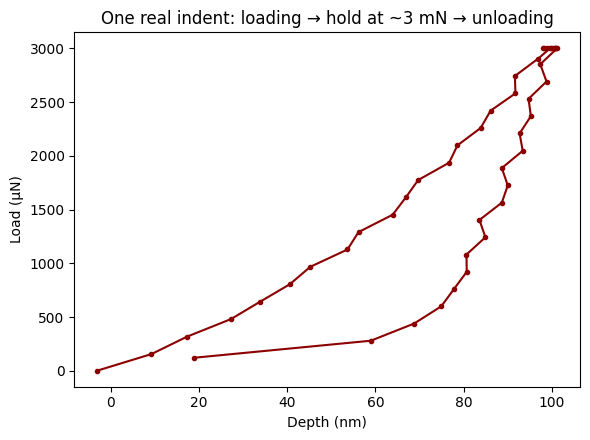

In [2]:
depth_nm = [-3.0, 9.25, 17.39, 27.3, 33.91, 40.62, 45.25, 53.68, 56.18, 63.92, 66.91, 69.7,
            76.72, 78.6, 83.86, 86.12, 91.75, 91.62, 96.89, 99.57, 98.3, 100.92, 98.07, 100.37,
            99.82, 100.81, 98.93, 100.64, 101.17, 97.38, 98.79, 94.71, 95.25, 92.69, 93.4, 88.66,
            90.01, 88.66, 83.59, 84.94, 80.65, 80.71, 77.81, 74.93, 68.8, 58.96, 18.98]
load_uN = [1.45, 155.3, 318.58, 481.15, 643.19, 804.98, 966.85, 1128.16, 1289.96, 1451.24, 1612.86,
           1774.06, 1935.48, 2096.76, 2258.03, 2419.44, 2580.56, 2742.03, 2903.15, 2998.12, 2998.18,
           2998.07, 2998.14, 2998.06, 2998.13, 2998.03, 2998.24, 2998.03, 2998.04, 2851.39, 2690.38,
           2529.33, 2368.27, 2207.43, 2046.23, 1885.47, 1724.38, 1563.54, 1402.78, 1241.92, 1081.11,
           920.43, 759.86, 599.33, 439.54, 279.42, 121.34]

plt.figure(figsize=(6, 4.5))
plt.plot(depth_nm, load_uN, marker='o', markersize=3, color='darkred')
plt.xlabel("Depth (nm)")
plt.ylabel("Load (µN)")
plt.title("One real indent: loading → hold at ~3 mN → unloading")
plt.tight_layout()
plt.show()


Notice the shape: load rises as the indenter pushes in, holds briefly at the target 3 mN, then falls as the indenter withdraws — but the depth doesn't fully return to zero (the material has deformed permanently). Features like `slope_0.2` (initial unloading slope), `work_elastic`/`work_plastic` (areas under different parts of this curve), and `h_ratio` all come directly from measurements on curves exactly like this one, for each of our 2,621 indents.

## Step 1 — Load the Real Dataset

In [3]:
TRAIN_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/Training_set.csv"
VAL_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/Validation_set.csv"

train = pd.read_csv(TRAIN_URL)
val = pd.read_csv(VAL_URL)

print("Training set:", train.shape)
print("Validation set:", val.shape)
train.head()


Training set: (2094, 20)
Validation set: (524, 20)


,Unnamed: 0,map_name,file_names,slope_0.2,norm_slope_0.2,curvature,curvature_linear,curvature_shift,norm_curvature,norm_curvature_linear,norm_curvature_shift,work_total,work_elastic,work_plastic,work_ratio,h_ratio,Er(GPa),H(GPa),mN,Y_name
0,0,SV-map1-3mN,SV-7-map1-indents_0030.txt,83393.350709,1.609633,198012.612277,42329.079405,-45.504174,0.224797,0.823695,-0.015178,81.023697,54.610370,26.413327,0.325995,0.733881,271.292415,30.016810,3,mc
1,1,SAV-map1-3mN,SA-7-map1-indent_0170.txt,116225.994897,3.520130,195849.039301,15343.983615,57.965433,0.534149,0.462785,0.019334,114.067688,37.944013,76.123675,0.667355,0.422292,229.969402,11.193505,3,matrix
2,2,LCV-map1-3mN,LCV-7-map1-indent_0286.txt,111921.521595,3.569106,155069.808333,16680.815621,46.814902,0.470438,0.530603,0.015614,119.292136,39.219278,80.072858,0.671233,0.491833,216.978379,10.569870,3,matrix
3,3,LCV-map2-3mN,LCV-8-map2-indent_0199.txt,112193.241911,3.345373,186398.067513,17695.771008,10.662438,0.491944,0.525007,0.003556,113.394544,42.508003,70.886541,0.625132,0.557541,234.532986,11.829912,3,matrix
4,4,BV-map2-3mN,3s-a9-b-map2-curves_0087.txt,115076.496491,3.581818,186869.915093,15322.904911,49.493028,0.535233,0.473605,0.016508,115.893629,33.133112,82.760517,0.714108,0.441654,226.274820,10.665761,3,matrix


## Step 2 — Explore the Data

In [4]:
print("Phase label distribution (training set):")
print(train['Y_name'].value_counts())
print()
print("Indentation loads present:", sorted(train['mN'].unique()))


Phase label distribution (training set):
Y_name
matrix        1329
mc-matrix      543
mc             106
m6c-matrix     101
m6c             15
Name: count, dtype: int64

Indentation loads present: [np.int64(3), np.int64(5), np.int64(10)]


Notice the class imbalance — `matrix` dominates, while `m6c` (M6C-type carbide) is rare. This matters later when we compare weighted vs. macro F1 scores.

## Step 3 — Filter and Prepare

In [5]:
# Match the original study's methodology: use only the 3 mN indentation series
train = train[train.mN == 3].copy()
val = val[val.mN == 3].copy()

label_map = {'matrix': 0, 'mc-matrix': 1, 'm6c-matrix': 2, 'mc': 3, 'm6c': 4}
inv_label_map = {v: k for k, v in label_map.items()}
train['Y'] = train['Y_name'].map(label_map)
val['Y'] = val['Y_name'].map(label_map)

print("Training rows (mN=3):", len(train), "| Validation rows (mN=3):", len(val))


Training rows (mN=3): 1642 | Validation rows (mN=3): 412


---
## Quick Check 1

K-means needs us to choose K in advance. There are 5 true phase labels in this dataset. Should we necessarily set K=5?

**(i)  Yes – always match K to the number of true classes**
**(ii)  Not necessarily – some labels represent transition/mixed indents, not distinct phases; the elbow method and silhouette score (from this morning's theory session) should guide K, informed by domain knowledge**
**(iii)  It doesn't matter what K is set to**

*Think about it, then check the answer below.*

**Answer: (ii)** — `mc-matrix` and `m6c-matrix` represent indents that span a matrix/carbide boundary, not a fourth and fifth distinct material phase. Domain knowledge suggests 3 real underlying phases (matrix, MC carbide, M6C carbide) is a more sensible target than blindly matching K to the label count. Let's check what the data itself says next.

## Step 4 — Choosing K: Elbow Method and Silhouette Score

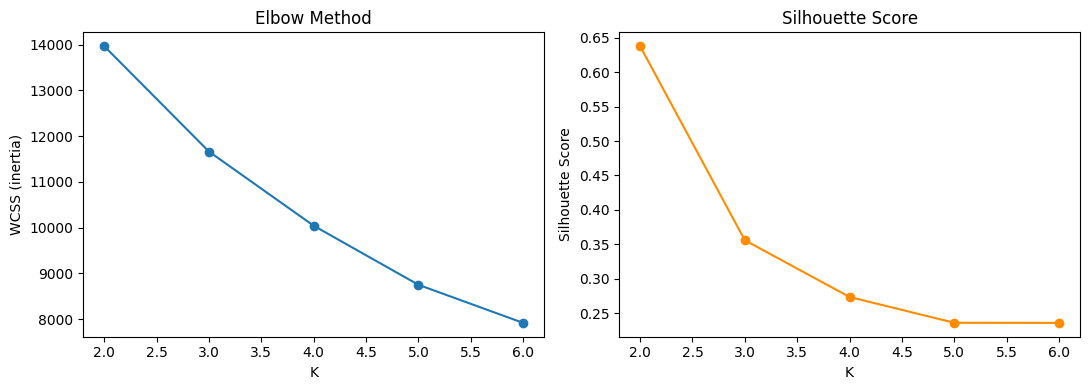

K=2: WCSS=13967, silhouette=0.638
K=3: WCSS=11664, silhouette=0.356
K=4: WCSS=10043, silhouette=0.273
K=5: WCSS=8753, silhouette=0.236
K=6: WCSS=7920, silhouette=0.236


In [6]:
engineered_features = ['slope_0.2', 'norm_slope_0.2', 'curvature', 'curvature_linear', 'curvature_shift',
                       'norm_curvature', 'norm_curvature_linear', 'norm_curvature_shift',
                       'work_total', 'work_elastic', 'work_plastic', 'work_ratio', 'h_ratio']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[engineered_features])

wcss, sil_scores = [], []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_train_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), wcss, marker='o')
axes[0].set_xlabel("K"); axes[0].set_ylabel("WCSS (inertia)"); axes[0].set_title("Elbow Method")
axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score")
plt.tight_layout()
plt.show()

for k, w, s in zip(k_range, wcss, sil_scores):
    print(f"K={k}: WCSS={w:.0f}, silhouette={s:.3f}")


**An honest result, worth discussing rather than glossing over:** silhouette score actually peaks at K=2, not K=3. Let's look at what K=2 vs. K=3 each actually separate before deciding.

In [7]:
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_train_scaled)
    train[f'cluster_k{k}'] = km.labels_
    print(f"--- K={k}: cluster composition by true label ---")
    print(pd.crosstab(train[f'cluster_k{k}'], train['Y_name']))
    print()


--- K=2: cluster composition by true label ---
Y_name      m6c  m6c-matrix  matrix  mc  mc-matrix
cluster_k2                                        
0             2           3       4  75         20
1             6          71    1082  18        361

--- K=3: cluster composition by true label ---
Y_name      m6c  m6c-matrix  matrix  mc  mc-matrix
cluster_k3                                        
0             3          24      60   9        212
1             3          49    1022  12        155
2             2           1       4  72         14



**What this shows:** K=2 mostly just separates “MC carbide” (very hard, statistically distinct) from everything else — a clean, high-silhouette split, but one that throws away the matrix-vs-M6C distinction entirely. K=3 captures a more metallurgically meaningful three-way structure, even though its silhouette score is lower.

**This is exactly this morning's lesson about troubleshooting:** a purely statistical metric (silhouette) doesn't automatically know what's metallurgically meaningful. Domain knowledge – three real phase constituents – justifies choosing **K=3** here, matching the original paper's own choice, even though K=2 “wins” on silhouette alone.

---
## Quick Check 2

Why might relying on silhouette score alone to choose K be misleading here?

**(i)  Silhouette score is never useful for real data**
**(ii)  The statistically “cleanest” split (K=2) discards a real metallurgical distinction (M6C vs. matrix) that we know exists from domain knowledge**
**(iii)  K=2 and K=3 give identical clustering results, so it doesn't matter**

*Think about it, then check the answer below.*

**Answer: (ii)** — silhouette score only measures geometric separation in feature space; it has no way to know that matrix and M6C carbide are metallurgically distinct phases worth distinguishing. This is a real limitation of automated metrics that domain expertise needs to override.

## Step 5 — A Reusable Evaluation Pipeline

Since K-means cluster IDs are arbitrary (cluster “0” has no inherent meaning), we map each cluster to whichever true label is most common within it — then evaluate against the real validation labels.

In [8]:
def cluster_and_evaluate(feature_list, name):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(train[feature_list])
    Xval = scaler.transform(val[feature_list])

    km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xtr)
    train_pred = km.predict(Xtr)
    val_pred = km.predict(Xval)

    # Map each cluster ID to its majority true label
    mapping = {}
    for cluster_id in np.unique(train_pred):
        mapping[cluster_id] = train['Y'][train_pred == cluster_id].mode()[0]
    val_pred_mapped = pd.Series(val_pred).map(mapping)

    f1_w = f1_score(val['Y'], val_pred_mapped, average='weighted')
    f1_m = f1_score(val['Y'], val_pred_mapped, average='macro')
    cm = confusion_matrix(val['Y'], val_pred_mapped, labels=[0, 1, 2, 3, 4])

    print(f"--- {name} ---")
    print(f"Validation F1 (weighted): {f1_w:.3f}")
    print(f"Validation F1 (macro):    {f1_m:.3f}")

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap='Blues')
    labels = [inv_label_map[i] for i in range(5)]
    ax.set_xticks(range(5)); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(5)); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name}: Confusion Matrix")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()

    return f1_w, f1_m


## Step 6 — Feature Set A: The Traditional Baseline

--- Feature Set A (baseline: Er, H) ---
Validation F1 (weighted): 0.686
Validation F1 (macro):    0.415


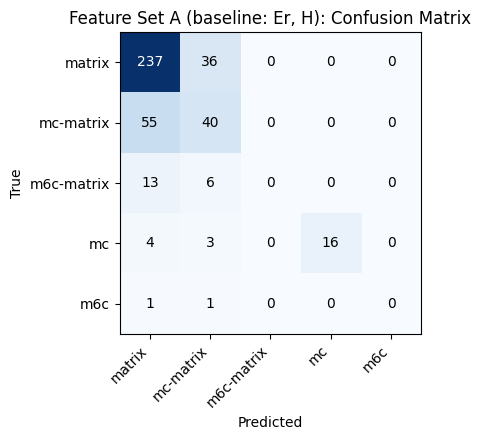

In [9]:
feature_set_A = ['Er(GPa)', 'H(GPa)']
f1w_A, f1m_A = cluster_and_evaluate(feature_set_A, "Feature Set A (baseline: Er, H)")


Notice: two of the five true phase categories (`m6c-matrix`, `m6c`) never appear in the *predicted* column at all — with only 3 clusters, the rarest classes can never be correctly captured. This is exactly why **macro F1** (which weighs every class equally) stays much lower than **weighted F1** (which is dominated by the common `matrix` class).

## Step 7 — Feature Set B: The Engineered Features

--- Feature Set B (13 engineered features) ---
Validation F1 (weighted): 0.763
Validation F1 (macro):    0.463


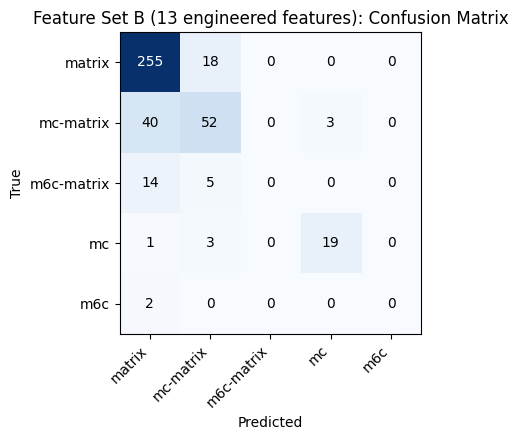

In [10]:
f1w_B, f1m_B = cluster_and_evaluate(engineered_features, "Feature Set B (13 engineered features)")


---
## Quick Check 3

Feature Set B uses 13 engineered features derived from load-displacement curves, instead of just Er and H. Based on the F1 scores you just saw, what does this suggest?

**(i)  More features always hurt clustering, regardless of what they measure**
**(ii)  Features genuinely capturing more of the curve's shape (not just peak modulus/hardness) give the clustering more to work with, improving separation of the phases**
**(iii)  The results are identical to Feature Set A**

*Think about it, then check the answer below.*

**Answer: (ii)** — the engineered features capture shape information (elastic/plastic work split, curvature, unloading slope) that Er and H alone discard. This is the paper's own headline finding: feature engineering measurably improves clustering quality here, using the exact same algorithm.

## Step 8 — Feature Set C: Baseline + Engineered, Combined

--- Feature Set C (combined, 15 features) ---
Validation F1 (weighted): 0.760
Validation F1 (macro):    0.469


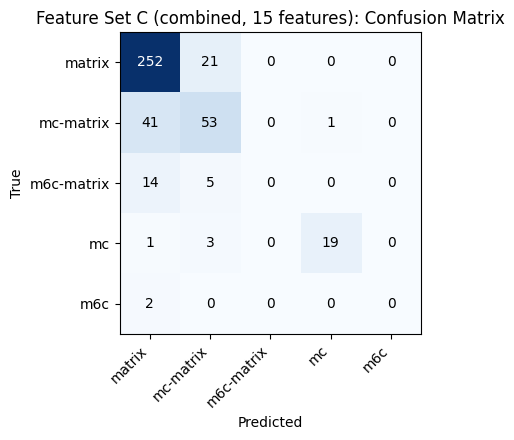

In [11]:
feature_set_C = feature_set_A + engineered_features
f1w_C, f1m_C = cluster_and_evaluate(feature_set_C, "Feature Set C (combined, 15 features)")


## Step 9 — Comparing All Three

   Feature Set  F1 weighted  F1 macro
  A (baseline)     0.686455  0.415108
B (engineered)     0.763427  0.463479
  C (combined)     0.760255  0.469417


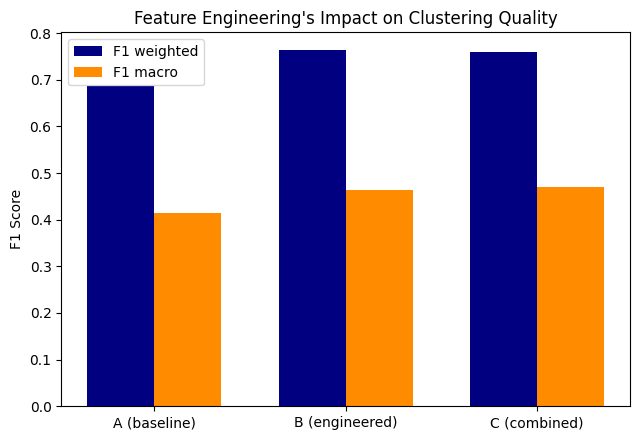

In [12]:
results = pd.DataFrame({
    'Feature Set': ['A (baseline)', 'B (engineered)', 'C (combined)'],
    'F1 weighted': [f1w_A, f1w_B, f1w_C],
    'F1 macro': [f1m_A, f1m_B, f1m_C],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, results['F1 weighted'], width, label='F1 weighted', color='navy')
ax.bar(x + width/2, results['F1 macro'], width, label='F1 macro', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(results['Feature Set'])
ax.set_ylabel("F1 Score")
ax.set_title("Feature Engineering's Impact on Clustering Quality")
ax.legend()
plt.tight_layout()
plt.show()


---
## Quick Check 4

Feature Set C (combined, 15 features) performs almost identically to Feature Set B (13 engineered features alone) – adding Er and H back in barely changes anything. What does this suggest?

**(i)  Er and H were never useful at all**
**(ii)  The engineered features already capture most of the same information that Er and H provide, so adding them back contributes little new signal**
**(iii)  The clustering algorithm ignores extra features automatically**

*Think about it, then check the answer below.*

**Answer: (ii)** — Er and H are themselves derived from the same underlying load-displacement curve, so much of their information is already implicitly present in the engineered features. This is a common pattern in feature engineering: once you've captured the richer signal, the simpler summary statistics add little on top.

## Wrap-Up

- Applied K-means to a **real, human-labelled dataset** of 2,621 nanoindentation measurements
- Chose K=3 using elbow + silhouette **and** domain knowledge – an honest example of when statistical metrics alone (which favored K=2) need to be weighed against what we actually know about the material
- Reproduced the source paper's own core finding: engineered features (B) clearly beat the traditional Er/H baseline (A); combining both (C) adds little further
- Saw directly why **macro F1 stays low** even when **weighted F1 looks good** – with only 3 clusters, the rarest true phases can never be correctly captured

**Next, in this same session:** dimensionality reduction (PCA) on these same 13 engineered features, then re-clustering in the reduced space – and (time permitting) a look at what unsupervised clustering finds when applied spatially across a real indentation map.

---
## Part B: Principal Component Analysis (PCA)

We just clustered these 2,621 measurements using up to 13 engineered features. Now: PCA — reducing those 13 features to fewer dimensions, and checking whether clustering quality survives.

### Recap: The Curse of Dimensionality

From this morning's theory session: as the number of features grows, distance-based similarity measures start to break down – in high dimensions, most points end up looking roughly equally “far apart,” making it harder for k-means to find genuine structure.

Our engineered feature set has **13 dimensions**. PCA lets us compress this down to fewer dimensions, keeping most of the meaningful variation, while (hopefully) keeping clustering quality intact.

## Step 10 — How Many Components Do We Actually Need?

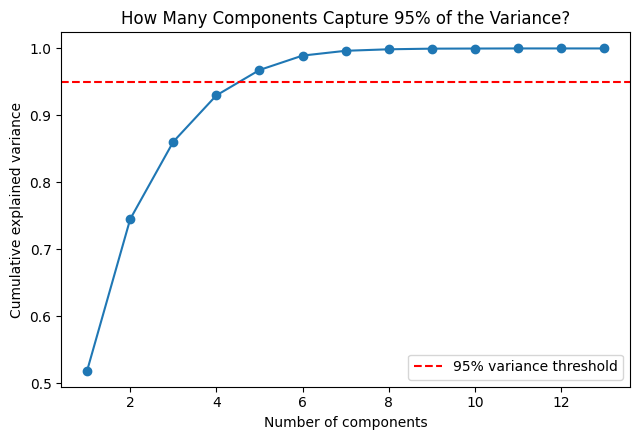

Components needed for 95% variance: 5 (out of 13 original features)
Cumulative variance by component: [0.519 0.745 0.861 0.93  0.968 0.989 0.996 0.999 1.    1.    1.    1.
 1.   ]


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[engineered_features])
X_val_scaled = scaler.transform(val[engineered_features])

pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6.5, 4.5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("How Many Components Capture 95% of the Variance?")
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95} (out of 13 original features)")
print("Cumulative variance by component:", np.round(cumulative_variance, 3))


---
## Quick Check 1

We need only 5 out of 13 original features' worth of information (as principal components) to retain 95% of the variance. What does this tell us about the original 13 engineered features?

**(i)  Most of them are completely useless and should be deleted**
**(ii)  Many of them are correlated with each other – they carry overlapping information, which PCA compresses into fewer independent components**
**(iii)  PCA has made a mistake; all 13 features must be equally important**

*Think about it, then check the answer below.*

**Answer: (ii)** — PCA doesn't discard “useless” features; it finds new axes (combinations of the originals) that capture the shared, correlated variation efficiently. Features like `curvature`, `curvature_linear`, and `curvature_shift` likely overlap heavily in what they measure – exactly the kind of redundancy PCA compresses away.

## Step 11 — Re-Clustering in the Reduced Space

In [14]:
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

km_pca = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_pca)
train_pred = km_pca.predict(X_train_pca)
val_pred = km_pca.predict(X_val_pca)

mapping = {}
for cluster_id in np.unique(train_pred):
    mapping[cluster_id] = train['Y'][train_pred == cluster_id].mode()[0]
val_pred_mapped = pd.Series(val_pred).map(mapping)

f1w_pca = f1_score(val['Y'], val_pred_mapped, average='weighted')
f1m_pca = f1_score(val['Y'], val_pred_mapped, average='macro')

print(f"PCA-reduced clustering ({n_components_95} dimensions instead of 13):")
print(f"  F1 weighted = {f1w_pca:.3f}")
print(f"  F1 macro    = {f1m_pca:.3f}")
print()
print(f"Compare to Part A's Feature Set B (full 13 dimensions): F1 weighted = {f1w_B:.3f}, macro = {f1m_B:.3f}")


PCA-reduced clustering (5 dimensions instead of 13):
  F1 weighted = 0.763
  F1 macro    = 0.463

Compare to Part A's Feature Set B (full 13 dimensions): F1 weighted = 0.763, macro = 0.463


**A clean result:** clustering in just 5 PCA dimensions gives (essentially) the **same F1 scores** as clustering in the full 13-dimensional space. We've compressed the feature set by more than half with no real loss in clustering quality – exactly the payoff PCA promises.

---
## Quick Check 2

Since PCA-reduced clustering performs about the same as using all 13 features, was reducing dimensionality pointless here?

**(i)  Yes – if performance doesn't improve, there's no benefit**
**(ii)  No – matching performance with fewer dimensions is itself valuable: faster computation, less risk from the curse of dimensionality on larger datasets, and it enables the 2D visualization we're about to make**
**(iii)  No – PCA always improves performance, and this is a hidden improvement**

*Think about it, then check the answer below.*

**Answer: (ii)** — “no worse, but simpler” is a genuine win. With a much larger dataset, or many more features, this same dimensionality reduction could matter a great deal for runtime – and as we're about to see, it also makes visualization possible.

## Step 12 — A Visualization Benefit: Seeing 13 Dimensions in 2D

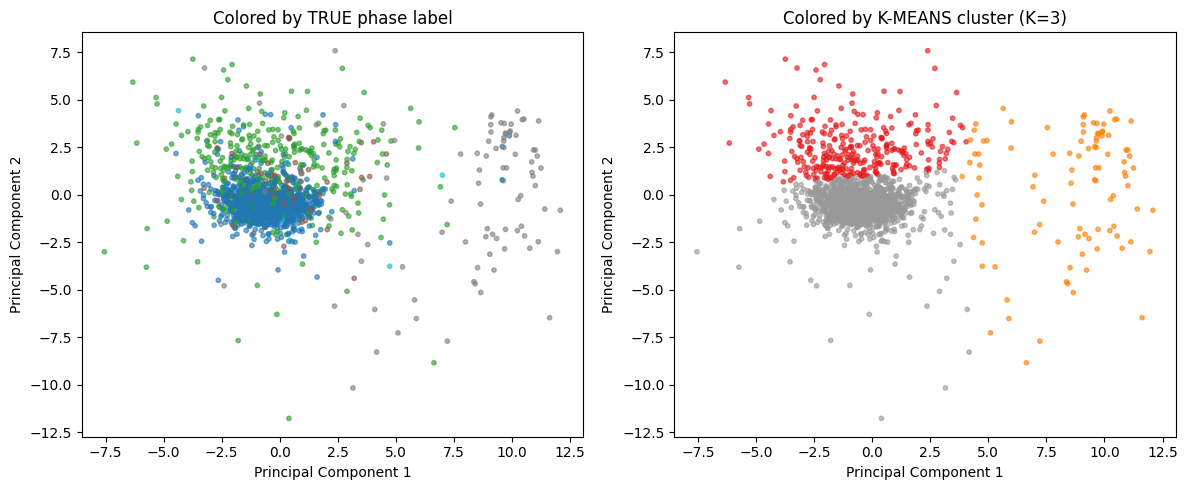

In [15]:
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=train['Y'], cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_title("Colored by TRUE phase label")

km_2d = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_2d)
scatter2 = axes[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=km_2d.labels_, cmap='Set1', s=10, alpha=0.6)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].set_title("Colored by K-MEANS cluster (K=3)")

plt.tight_layout()
plt.show()


This is something we simply couldn't do with the original 13 dimensions – you can't plot 13 axes on a screen. Reducing to 2 components (even though 2 alone doesn't hit 95% variance) lets us visually compare where k-means' clusters land against the true phase labels, side by side.

---
## ⭐ Optional / Stretch — Part C: Applying Clustering to a Real Spatial Map

Everything above is the core material for this session. What follows is a self-contained bonus application — feel free to run it now if time allows, or explore it on your own afterward. It doesn't introduce new methodology; it applies what we've already built to a real spatial indentation map, turning cluster predictions into an actual microstructure picture.

## Step 13 — Fit Feature Set A on the Training Data

In [16]:
feature_set_A = ['Er(GPa)', 'H(GPa)']
scaler_A = StandardScaler()
X_train_A = scaler_A.fit_transform(train[feature_set_A])

km_A = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_A)
train_pred_A = km_A.predict(X_train_A)

mapping_A = {}
for cluster_id in np.unique(train_pred_A):
    mapping_A[cluster_id] = train['Y'][train_pred_A == cluster_id].mode()[0]

print("Cluster -> phase label mapping (Feature Set A):")
for cid, label_id in mapping_A.items():
    print(f"  Cluster {cid}  ->  {inv_label_map[label_id]}")


Cluster -> phase label mapping (Feature Set A):
  Cluster 0  ->  mc-matrix
  Cluster 1  ->  mc
  Cluster 2  ->  matrix


## Step 14 — Load the Spatial Map and Predict

In [17]:
MAP_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/HSS_BW_3mN_map01%20LC.txt"
wurfel = pd.read_csv(MAP_URL, sep="\t", skiprows=1, encoding="latin-1")

print("Spatial map shape:", wurfel.shape)

X_wurfel = scaler_A.transform(wurfel[feature_set_A])
wurfel_cluster = km_A.predict(X_wurfel)
wurfel['predicted_label'] = pd.Series(wurfel_cluster).map(mapping_A).map(inv_label_map)

print()
print("Predicted phase distribution across this map:")
print(wurfel['predicted_label'].value_counts())

Spatial map shape: (400, 15)

Predicted phase distribution across this map:
predicted_label
matrix       272
mc-matrix    113
mc            15
Name: count, dtype: int64


## Step 15 — Visualizing the Predicted Microstructure Map

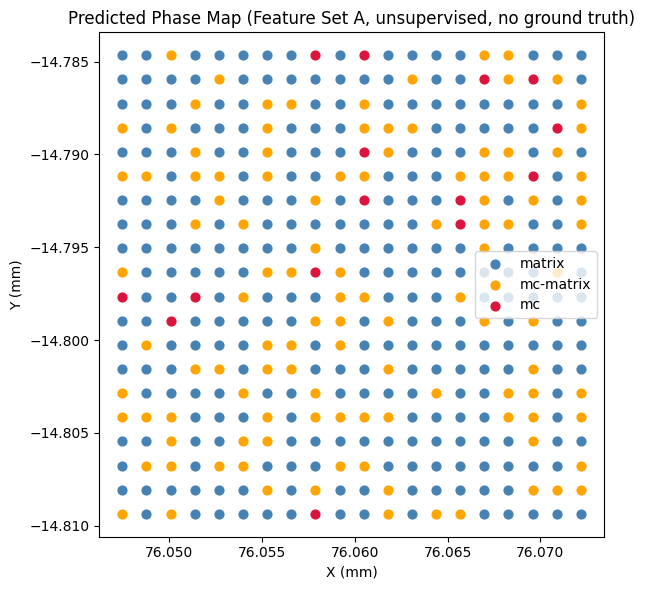

In [18]:
label_colors = {'matrix': 'steelblue', 'mc-matrix': 'orange', 'mc': 'crimson',
                'm6c-matrix': 'green', 'm6c': 'purple'}

plt.figure(figsize=(7, 6))
for label, color in label_colors.items():
    subset = wurfel[wurfel.predicted_label == label]
    if len(subset) > 0:
        plt.scatter(subset['X(mm)'], subset['Y(mm)'], c=color, label=label, s=40)

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Predicted Phase Map (Feature Set A, unsupervised, no ground truth)")
plt.legend()
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()


Notice how the predicted phases aren't randomly scattered – they form spatially coherent regions, which is exactly what we'd expect if the clustering is picking up genuine microstructural features (a matrix phase with embedded carbide regions), rather than noise. Since we have no ground truth for this specific map, we can't quantify accuracy here – but the spatial coherence itself is a reasonable, honest sanity check that the clustering is doing something metallurgically sensible.

---
## Quick Check 3

Since we have no ground-truth labels for this spatial map, what's the most responsible way to interpret the predicted phase map above?

**(i)  Treat it as a fully validated, guaranteed-accurate phase map**
**(ii)  Treat it as a plausible, spatially-coherent hypothesis worth further verification (e.g., against a metallurgist's visual inspection), not a proven result**
**(iii)  Ignore it entirely, since without ground truth it has no value**

*Think about it, then check the answer below.*

**Answer: (ii)** — the spatial coherence is a genuinely encouraging sign, but without ground truth we can't claim validated accuracy. This is the honest, realistic position for most real unsupervised clustering applications – useful, suggestive, but not a substitute for expert verification.

## Wrap-Up: The Clustering Topic, End to End

Across today's two clustering sessions:

- **Session 3 (theory)** – the K-means algorithm itself: assign/update, cost function, manual similarity measures, choosing K (elbow, silhouette), evaluating results, the broader algorithm landscape (centroid/density/distribution/hierarchical), the clustering workflow, and real limitations (spherical-cluster assumption, curse of dimensionality)
- **Session 4 (this practical)** – applying K-means to 2,621 real, human-labelled nanoindentation measurements, reproducing a published paper's own finding that feature engineering matters more than adding more features for its own sake; PCA for dimensionality reduction (same performance, fewer dimensions, enables visualization); and (optionally) a real spatial microstructure application

**Next: Day 4 begins a new topic.**